IMPORTING LIBRARIES 

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

Taking user input 

In [7]:
stock_name = input("Enter stock ticker: ")
start_date = input("Enter start date : ")
end_date = input("Enter end date: ")
timeframe = input("Enter timeframe: ")

Enter stock ticker:  AAPL
Enter start date :  2020-01-01
Enter end date:  2025-01-01
Enter timeframe:  1d


In [8]:
data = yf.download(stock_name,start=start_date,end=end_date, interval = timeframe)
data.columns = data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [9]:
print(data.head())

Price           Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.333870  72.394078  71.091176  71.344047  135480400
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861862  72.466345  71.642704  72.211064  108872000
2020-01-08  73.017838  73.318877  71.565621  71.565621  132079200


Ploting the graph for closing price of the stock

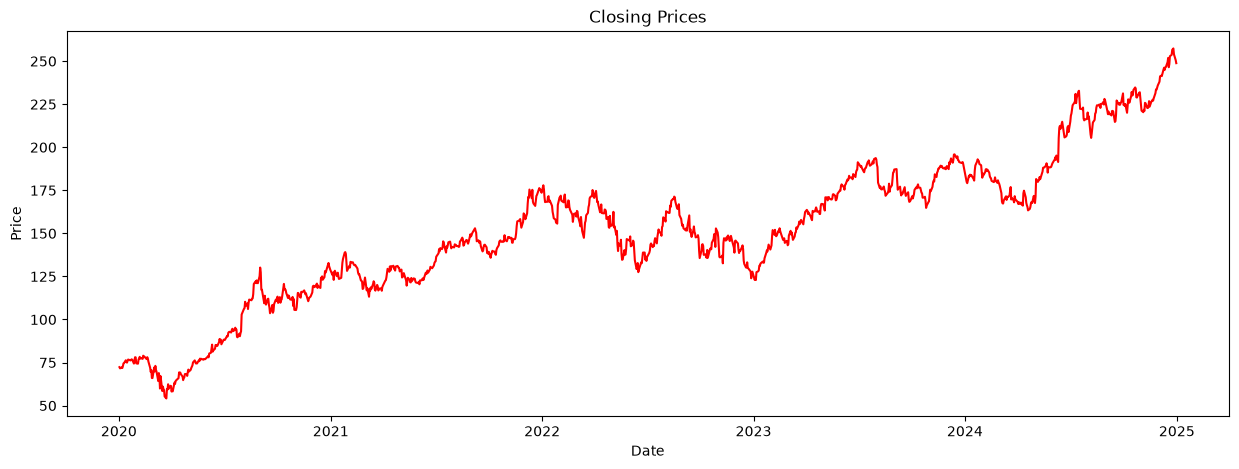

In [28]:
plt.figure(figsize=(15,5))
plt.plot(data.index, data['Close'], color='red')
plt.title('Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.savefig("closing_price.png")
plt.show()

for MACD

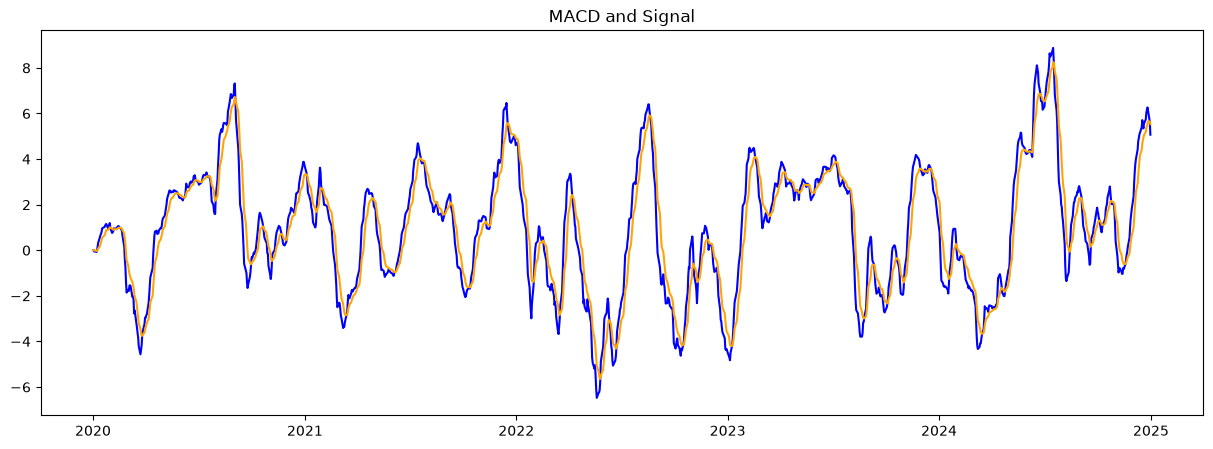

In [29]:
data['MACD']=(data['Close'].ewm(span=12, adjust=False).mean())-(data['Close'].ewm(span=26, adjust=False).mean())
data['MACD_Signal']=data['MACD'].ewm(span=9, adjust=False).mean()
plt.figure(figsize=(15,5))
plt.plot(data['MACD'],color='blue',label='MACD line')
plt.plot(data['MACD_Signal'],color='orange',label='Signal line')
plt.title('MACD and Signal')
plt.savefig("closing_price.png")
plt.show()

For RSI

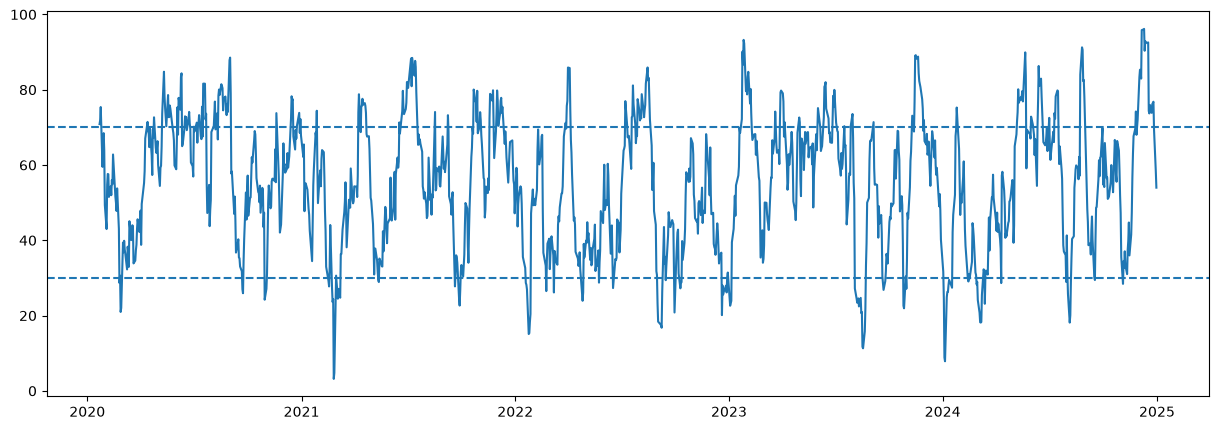

In [30]:
delta = data['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))
data['RSI'] = rsi
plt.figure(figsize=(15,5))
plt.plot(data['RSI'])
plt.axhline(70, linestyle='--', label='Overbought')
plt.axhline(30, linestyle='--', label='Oversold')
plt.savefig("closing_price.png")
plt.show()

RSI was selected to capture momentum and overbought/oversold conditions,
while MACD was selected to capture trend strength and momentum shifts.
Together with the closing price, these features provide the LSTM model with information about price level, trend, and market momentum."

Creating new data frame for the 3 parameters to be used

In [13]:
data_features = data.filter(['Close', 'MACD', 'RSI'])
dataset = data_features.values

Dropping the Nan values as for macd the initial 14 would behaving

In [14]:
data_features = data_features.dropna()
dataset = data_features.values

Scaling

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)


Making data ready for training

In [16]:
size = 60
predict_size=15

X = []
y = []

for i in range(size, len(scaled_data)-predict_size):
    
    #calculating the previous 60 days
    previousdays = scaled_data[i-size:i]
    
    #and
    targetprice = scaled_data[i:i+predict_size, 0]

    X.append(previousdays)
    y.append(targetprice)

Checking the shape

In [17]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

X=np.array(X)
y=np.array(y)

(1170, 60, 3)
(1170, 15)


split the data for training and testing


 shuffle is false because it is a time series example

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False,random_state=1)

LSTM model

In [19]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


Build the model

In [20]:
model = Sequential()

First Layer

In [21]:
model.add(LSTM(units=64,return_sequences=True,input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))


C:\Users\Riva\lstm_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Second layer

In [22]:
model.add(LSTM(units=32,return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(15))
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             495 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,375 (122.56 KB)

 Trainable params: 31,375 (122.56 KB)

 Non-trainable params: 0 (0.00 B)

training

In [23]:
history = model.fit(X_train,y_train,epochs=30,batch_size=32,validation_data=(X_test, y_test))

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - loss: 0.1304 - val_loss: 0.1500
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0237 - val_loss: 0.0260
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0104 - val_loss: 0.0147
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0079 - val_loss: 0.0169
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0068 - val_loss: 0.0081
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - loss: 0.0057 - val_loss: 0.0084
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - loss: 0.0052 - val_loss: 0.0169
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0050 - val_loss: 0.0073
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0045 - val_loss: 0.0102
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0043 - val_loss: 0.0033
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss:

pridict

In [24]:
predictions = model.predict(X_test)
print(predictions.shape)

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test.flatten(),predictions.flatten()))
print("RMSE =", rmse)



8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
(234, 15)
RMSE = 0.07913076554136701


Plotting

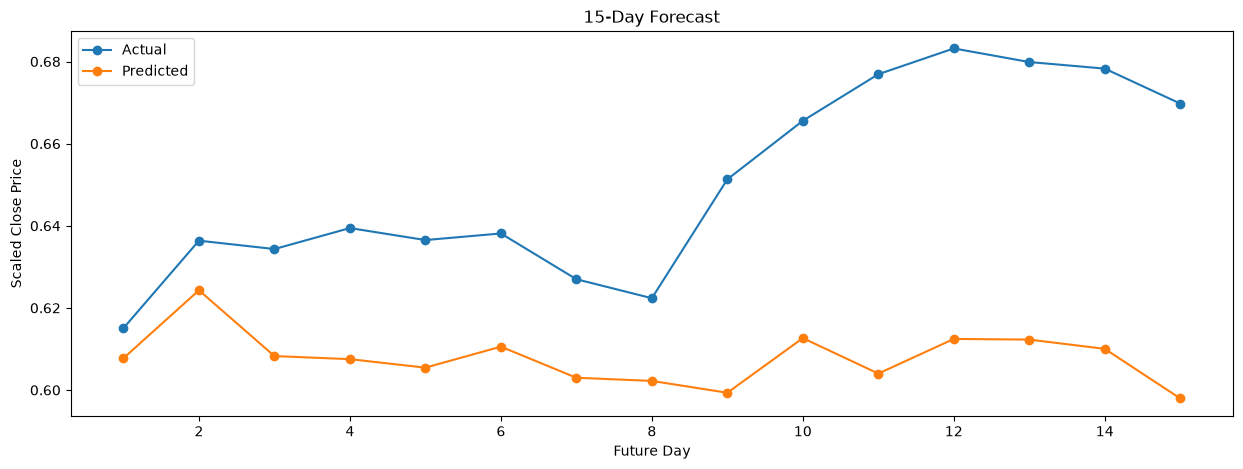

In [31]:
plt.figure(figsize=(15,5))
plt.plot(range(1,16),y_test[0],marker='o',label='Actual')
plt.plot(range(1,16),predictions[0],marker='o',label='Predicted')
plt.xlabel("Future Day")
plt.ylabel("Scaled Close Price")
plt.title("15-Day Forecast")
plt.legend()
plt.savefig("closing_price.png")
plt.show()




In [26]:
latest_60_days = scaled_data[-60:]
latest_60_days = latest_60_days.reshape(1,60,3)
future_15_days = model.predict(latest_60_days)
print("Predicted next 15 days:")
print(future_15_days[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicted next 15 days:
[0.93184364 0.9303752  0.91691345 0.91212106 0.9098154  0.9235702
 0.9097318  0.90064484 0.8992766  0.9179508  0.8937658  0.92849606
 0.9117147  0.9037817  0.8955518 ]


calculating r^2

In [27]:
numerator = np.sum((y_test - predictions) ** 2)
denominator = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (numerator / denominator)
print("R² Score:", r2)

R² Score: 0.5727281625383858
